# Notebook 02 — Self-Attention from Scratch

**Goal:** Build scaled dot-product attention from scratch and understand what the attention matrix means.

```
input embeddings  [seq_len, d_model]
   │
   ▼  linear projections  W_q, W_k, W_v
Q, K, V  [seq_len, d_k]
   │
   ▼  QKᵀ / √d_k  →  softmax
attention weights  [seq_len, seq_len]
   │
   ▼  weights @ V
contextualised output  [seq_len, d_model]
```

---

### Contents
1. [Queries, Keys, and Values](#1)
2. [Scaled dot-product attention](#2)
3. [A worked example](#3)
4. [Why scaling matters](#4)
5. [Causal masking](#5)
6. [Key takeaways](#6)


In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import math, sys, os
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, os.path.abspath('.'))
from utils.visualisation import plot_attention_heatmap

# ── Reproducibility ───────────────────────────────────────────────────────────
torch.manual_seed(42)
np.random.seed(42)

# ── Plot style ────────────────────────────────────────────────────────────────
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print('=' * 60)
print('  Notebook 02 — Self-Attention from Scratch')
print('=' * 60)
print(f'  PyTorch : {torch.__version__}')
print('=' * 60)


  Notebook 02 — Self-Attention from Scratch
  PyTorch : 2.11.0


<a id='1'></a>
## 1 — Queries, Keys, and Values

Self-attention gives each token three roles simultaneously:

| Vector | Role | Analogy |
|--------|------|---------|
| **Query (Q)** | "What am I looking for?" | A search query |
| **Key (K)** | "What do I contain?" | An index label |
| **Value (V)** | "What information do I carry?" | The actual content |

In practice Q, K, V are produced by learned linear projections of the input:

```
Q = X @ W_q    K = X @ W_k    V = X @ W_v
```

Self-attention computes a **weighted combination of values**, where the weights
depend on how well each query matches each key.


<a id='2'></a>
## 2 — Scaled dot-product attention

$$
\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^T}{\sqrt{d_k}}\right)V
$$

Steps:
1. **Score**: dot-product of every query with every key → raw similarity
2. **Scale**: divide by $\sqrt{d_k}$ to keep values well-behaved
3. **Mask** (optional): block future positions for autoregressive models
4. **Softmax**: turn each row into a probability distribution
5. **Aggregate**: weighted sum of value vectors


In [2]:
def scaled_dot_product_attention(Q, K, V, mask=None):
    """
    Q, K : (..., seq_len, d_k)
    V    : (..., seq_len, d_v)
    mask : (..., seq_len, seq_len)  True = block this position
    Returns: output (..., seq_len, d_v), weights (..., seq_len, seq_len)
    """
    d_k = Q.size(-1)

    # ── Step 1 & 2: scaled similarity scores ─────────────────────────────────
    # Q @ K^T gives (seq_len, seq_len) — similarity of each query to each key
    scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)

    # ── Step 3: optional mask (set blocked positions to -inf) ─────────────────
    if mask is not None:
        scores = scores.masked_fill(mask, float('-inf'))

    # ── Step 4: softmax row-wise → attention weights (each row sums to 1) ────
    weights = F.softmax(scores, dim=-1)
    weights = torch.nan_to_num(weights, nan=0.0)   # handle all-masked rows

    # ── Step 5: weighted sum of values ────────────────────────────────────────
    output = torch.matmul(weights, V)

    return output, weights


<a id='3'></a>
## 3 — A worked example

We'll use four tokens with 3-D embeddings.  Setting `Q = K = V = X` (no learned
projections yet) keeps the focus purely on the attention computation.


In [3]:
# ── Tiny example: 4 tokens, 3-D embeddings ───────────────────────────────────
tokens = ['The', 'cat', 'sat', 'down']

X = torch.tensor([
    [1.0, 0.0, 1.0],   # 'The'
    [0.0, 1.0, 1.0],   # 'cat'
    [1.0, 1.0, 0.0],   # 'sat'
    [0.0, 0.0, 1.0],   # 'down'
])   # shape: (seq_len=4, d_model=3)

# Identity projection: Q = K = V = X
output, weights = scaled_dot_product_attention(X, X, X)

print('Attention weights (each row sums to 1.0):')
for i, tok in enumerate(tokens):
    w = weights[i].numpy()
    print(f'  {tok:>4s}: {[round(float(x), 3) for x in w]}')
print()
print('Output (contextualised embeddings):')
print(output)


Attention weights (each row sums to 1.0):
   The: [0.373, 0.209, 0.209, 0.209]
   cat: [0.209, 0.373, 0.209, 0.209]
   sat: [0.23, 0.23, 0.41, 0.129]
  down: [0.281, 0.281, 0.158, 0.281]

Output (contextualised embeddings):
tensor([[0.5817, 0.4183, 0.7909],
        [0.4183, 0.5817, 0.7909],
        [0.6405, 0.6405, 0.5898],
        [0.4384, 0.4384, 0.8424]])


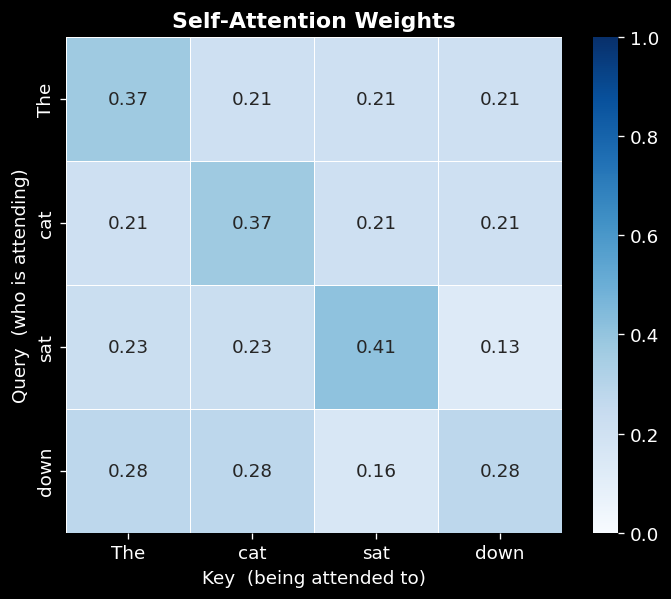

Row i = how token i distributes its attention.
Output[i] = weighted average of all value vectors, using row i as weights.


In [4]:
# ── Heatmap: who attends to whom? ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    weights.numpy(),
    annot=True, fmt='.2f',
    cmap='Blues', vmin=0, vmax=1,
    xticklabels=tokens, yticklabels=tokens,
    linewidths=0.4, linecolor='white',
    square=True, ax=ax,
)
ax.set_title('Self-Attention Weights', fontweight='bold')
ax.set_xlabel('Key  (being attended to)')
ax.set_ylabel('Query  (who is attending)')
plt.tight_layout()
plt.show()

print('Row i = how token i distributes its attention.')
print('Output[i] = weighted average of all value vectors, using row i as weights.')


<a id='4'></a>
## 4 — Why scaling matters

Without the $\sqrt{d_k}$ divisor, dot-products grow in magnitude as $d_k$ increases.
This pushes softmax into saturation — almost all weight on one key — which
kills gradient flow during training.


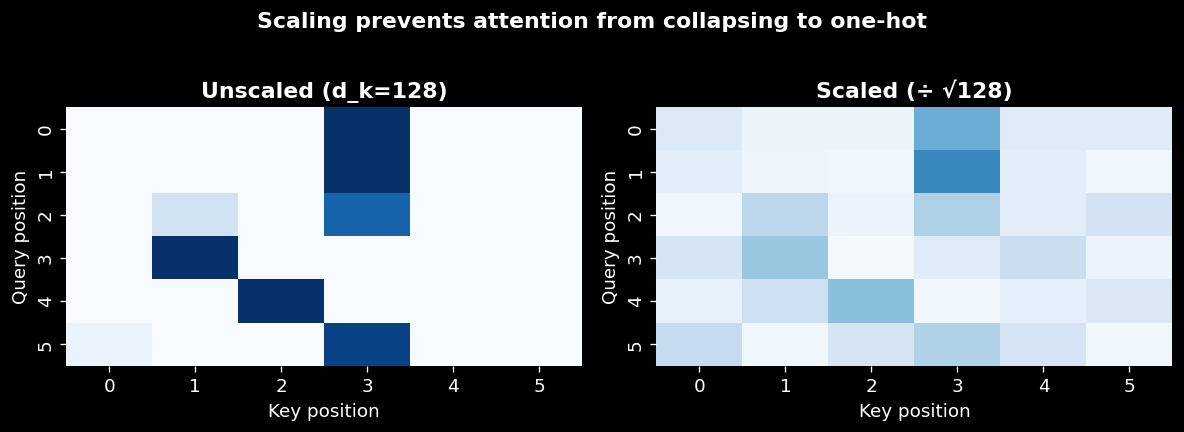

Unscaled — max weight in a row: 1.0000  (nearly one-hot)
Scaled   — max weight in a row: 0.6578  (spread out)


In [5]:
# ── Compare softmax sharpness: unscaled vs scaled ────────────────────────────
seq_len_demo, d_k_demo = 6, 128
Q_big = torch.randn(seq_len_demo, d_k_demo)
K_big = torch.randn(seq_len_demo, d_k_demo)

raw_scores    = Q_big @ K_big.T                   # unscaled
scaled_scores = raw_scores / math.sqrt(d_k_demo)  # scaled

w_raw    = F.softmax(raw_scores,    dim=-1)
w_scaled = F.softmax(scaled_scores, dim=-1)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for ax, w, title in zip(axes,
                         [w_raw, w_scaled],
                         ['Unscaled (d_k=128)', f'Scaled (÷ √{d_k_demo})']):
    sns.heatmap(w.numpy(), cmap='Blues', vmin=0, vmax=1, cbar=False, ax=ax)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Key position')
    ax.set_ylabel('Query position')

plt.suptitle('Scaling prevents attention from collapsing to one-hot',
             y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Unscaled — max weight in a row: {w_raw.max():.4f}  (nearly one-hot)')
print(f'Scaled   — max weight in a row: {w_scaled.max():.4f}  (spread out)')


<a id='5'></a>
## 5 — Causal masking

GPT-style models are **autoregressive**: when predicting token *i* they must not
see tokens *i+1, i+2, …* (those don't exist yet at generation time).

We enforce this with an upper-triangular mask that sets future positions to $-\infty$
before the softmax, so they receive zero attention weight.


Causal mask  (1 = blocked):
tensor([[0, 1, 1, 1],
        [0, 0, 1, 1],
        [0, 0, 0, 1],
        [0, 0, 0, 0]], dtype=torch.int32)


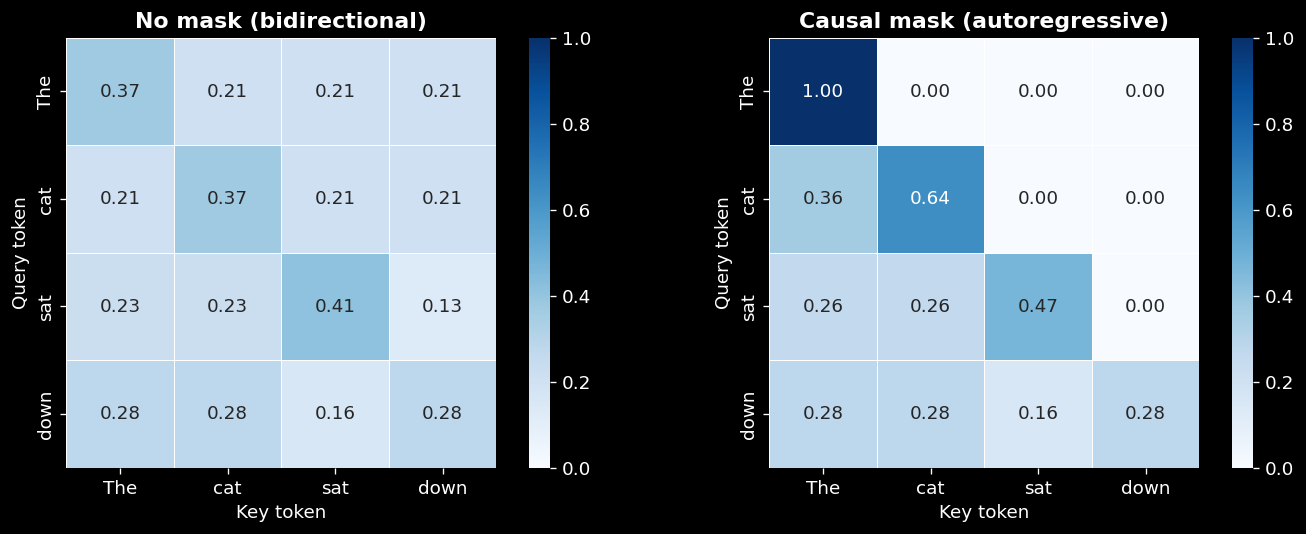

Upper triangle is zero — each token can only attend to itself and past tokens.


In [6]:
# ── Build causal mask: True = blocked ─────────────────────────────────────────
seq_len = len(tokens)
causal_mask = torch.triu(
    torch.ones(seq_len, seq_len, dtype=torch.bool),
    diagonal=1,
)
print('Causal mask  (1 = blocked):')
print(causal_mask.int())

_, weights_masked = scaled_dot_product_attention(X, X, X, mask=causal_mask)

# ── Side-by-side comparison ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, w, title in zip(axes,
                          [weights, weights_masked],
                          ['No mask (bidirectional)', 'Causal mask (autoregressive)']):
    sns.heatmap(w.numpy(), annot=True, fmt='.2f',
                cmap='Blues', vmin=0, vmax=1,
                xticklabels=tokens, yticklabels=tokens,
                linewidths=0.4, linecolor='white',
                square=True, ax=ax)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Key token')
    ax.set_ylabel('Query token')

plt.tight_layout()
plt.show()

print('Upper triangle is zero — each token can only attend to itself and past tokens.')


<a id='6'></a>
## 6 — Key takeaways

| Concept | What it does |
|---------|-------------|
| **Q / K / V** | Q finds relevant tokens via K; output is a weighted sum of V |
| **Dot product QKᵀ** | Measures similarity between each (query, key) pair |
| **Scaling ÷ √d_k** | Keeps scores well-behaved as embedding dimension grows |
| **Softmax** | Converts each row of scores to a probability distribution |
| **Causal mask** | Prevents tokens from attending to future positions |
| **Output** | Contextualised representation — each token informed by those it attends to |

**Next:** Notebook 03 runs multiple attention heads in parallel.
